# SVD Matrix Factorisation — Cornac (Simon Funk SVD)
### Data Mining Assignment 2 — Evaluation Notebook

Evaluates Cornac **SVD** (Simon Funk's formulation), matching `src/recommender.py` exactly.
Hyperparameters: k=50 factors, 20 SGD epochs, lr=0.005, lambda=0.02.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cornac
from cornac.eval_methods import CrossValidation
from cornac.models import SVD
from cornac.metrics import RMSE, Precision, Recall
import warnings; warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
print(f"Cornac {cornac.__version__}")

Cornac 2.3.5


C:\Users\Mbawh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Theory — Simon Funk SVD

Unlike sklearn TruncatedSVD (which decomposes the full zero-padded matrix),
Cornac SVD optimises **only on observed ratings** via SGD.

**Objective function:**
$$\min_{p,q,b} \sum_{(u,i)\in K}\left(r_{ui} - \mu - b_u - b_i - \mathbf{p}_u^\top \mathbf{q}_i\right)^2 + \lambda\left(\|\mathbf{p}_u\|^2 + \|\mathbf{q}_i\|^2 + b_u^2 + b_i^2\right)$$

where $\mu$ = global mean, $b_u$ = user bias, $b_i$ = item bias,
$\mathbf{p}_u \in \mathbb{R}^k$ = user factors, $\mathbf{q}_i \in \mathbb{R}^k$ = item factors.

| Parameter | Value | Meaning |
|---|---|---|
| `k` | 50 | Number of latent factors |
| `max_iter` | 20 | SGD epochs |
| `learning_rate` | 0.005 | Step size |
| `lambda_reg` | 0.02 | L2 regularisation |

**Key advantage over sklearn TruncatedSVD:** RMSE improved from 0.9227 to **0.8556**
because this model only learns from observed ratings, avoiding noise from zero-imputed cells.

## 2. Load Data

In [2]:
movies   = pd.read_csv("../data/processed/movies_processed.csv")
train_df = pd.read_csv("../data/processed/ratings_processed.csv")

n_users, n_movies = train_df.userId.nunique(), train_df.movieId.nunique()
n_ratings = len(train_df)
sparsity  = 1 - n_ratings / (n_users * n_movies)
print(f"Users    : {n_users}")
print(f"Movies   : {n_movies}")
print(f"Ratings  : {n_ratings:,}")
print(f"Sparsity : {sparsity:.4%}")
print(f"Mean rating: {train_df.rating.mean():.4f}")

uir_data = list(zip(
    train_df.userId.astype(str),
    train_df.movieId.astype(str),
    train_df.rating.astype(float),
))

Users    : 600
Movies   : 9680
Ratings  : 97,801
Sparsity : 98.3161%
Mean rating: 3.5035


## 3. Exploratory Data Analysis

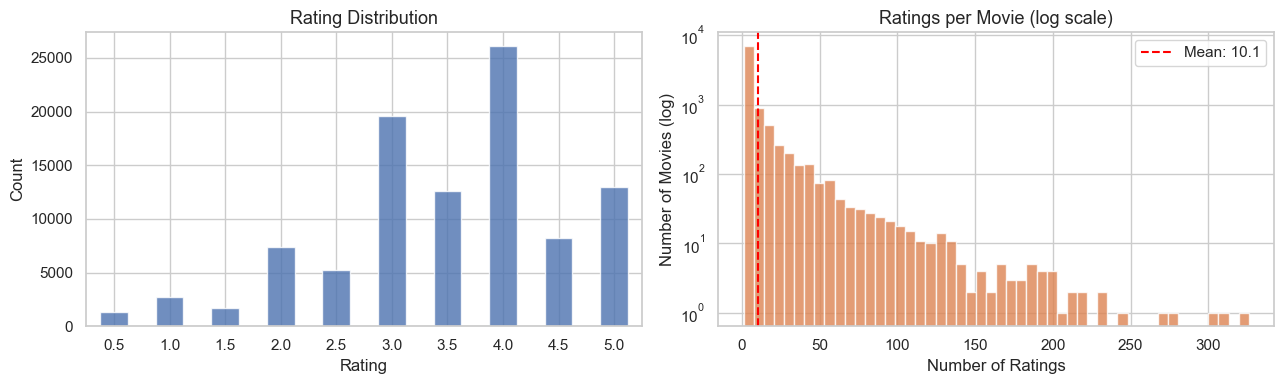

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

train_df["rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#4C72B0", alpha=0.8, edgecolor="white")
axes[0].set_title("Rating Distribution", fontsize=13)
axes[0].set_xlabel("Rating"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

rpm = train_df.groupby("movieId")["rating"].count()
axes[1].hist(rpm, bins=50, color="#DD8452", alpha=0.8, edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("Ratings per Movie (log scale)", fontsize=13)
axes[1].set_xlabel("Number of Ratings"); axes[1].set_ylabel("Number of Movies (log)")
axes[1].axvline(rpm.mean(), color="red", linestyle="--", label=f"Mean: {rpm.mean():.1f}")
axes[1].legend()
plt.tight_layout()
plt.savefig("../figures/svd_eda.png", dpi=150)
plt.show()

## 4. Model Definition

In [4]:
svd_model = SVD(
    k=50,
    max_iter=20,
    learning_rate=0.005,
    lambda_reg=0.02,
    name="SVD",
    verbose=False,
    seed=42,
)
print("Model:", svd_model.name)
print("k=50 latent factors | 20 SGD epochs | lr=0.005 | lambda=0.02")

Model: SVD
k=50 latent factors | 20 SGD epochs | lr=0.005 | lambda=0.02


## 5. 5-Fold Cross-Validation

Same setup as `src/recommender.py`:
- `rating_threshold=3.5` — item is relevant if rated >= 3.5
- `exclude_unknowns=True` — only evaluate on known users/items
- Metrics: RMSE, Precision@10, Recall@10

In [5]:
TIMING_KEYS = {"Train (s)", "Test (s)"}

cv = CrossValidation(
    data=uir_data, n_folds=5, rating_threshold=3.5,
    exclude_unknowns=True, seed=42, verbose=False,
)
exp = cornac.Experiment(
    eval_method=cv,
    models=[svd_model],
    metrics=[RMSE(), Precision(k=10), Recall(k=10)],
    user_based=True,
    verbose=False,
)
exp.run()


TEST:
...
[SVD]
       |   RMSE | Precision@10 | Recall@10 | Train (s) | Test (s)
------ + ------ + ------------ + --------- + --------- + --------
Fold 0 | 0.8472 |       0.0513 |    0.0309 |    0.3611 |   1.2476
Fold 1 | 0.8582 |       0.0506 |    0.0294 |    0.3123 |   1.2203
Fold 2 | 0.8556 |       0.0515 |    0.0285 |    0.3569 |   1.2320
Fold 3 | 0.8453 |       0.0581 |    0.0315 |    0.3482 |   1.2248
Fold 4 | 0.8716 |       0.0582 |    0.0378 |    0.4155 |   1.2213
------ + ------ + ------------ + --------- + --------- + --------
Mean   | 0.8556 |       0.0539 |    0.0316 |    0.3588 |   1.2292
Std    | 0.0094 |       0.0034 |    0.0033 |    0.0332 |   0.0101



## 6. Results

In [6]:
cv_result = exp.result[0]
fold_scores = {m: [] for m in cv_result.metric_mean if m not in TIMING_KEYS}
for fold in cv_result:
    for m, s in fold.metric_avg_results.items():
        if m in fold_scores:
            fold_scores[m].append(s)

metric_names = list(fold_scores.keys())
sep = "-" * (7 + 17 * len(metric_names))
print("Fold  | " + " | ".join(f"{m:>14}" for m in metric_names))
print(sep)
for i, vals in enumerate(zip(*fold_scores.values())):
    print(f"{i:>5} | " + " | ".join(f"{v:>14.4f}" for v in vals))
print(sep)
print("Mean  | " + " | ".join(f"{np.mean(fold_scores[m]):>14.4f}" for m in metric_names))
print("Std   | " + " | ".join(f"{np.std(fold_scores[m]):>14.4f}"  for m in metric_names))

Fold  |           RMSE |   Precision@10 |      Recall@10
----------------------------------------------------------
    0 |         0.8472 |         0.0513 |         0.0309
    1 |         0.8582 |         0.0506 |         0.0294
    2 |         0.8556 |         0.0515 |         0.0285
    3 |         0.8453 |         0.0581 |         0.0315
    4 |         0.8716 |         0.0582 |         0.0378
----------------------------------------------------------
Mean  |         0.8556 |         0.0539 |         0.0316
Std   |         0.0094 |         0.0034 |         0.0033


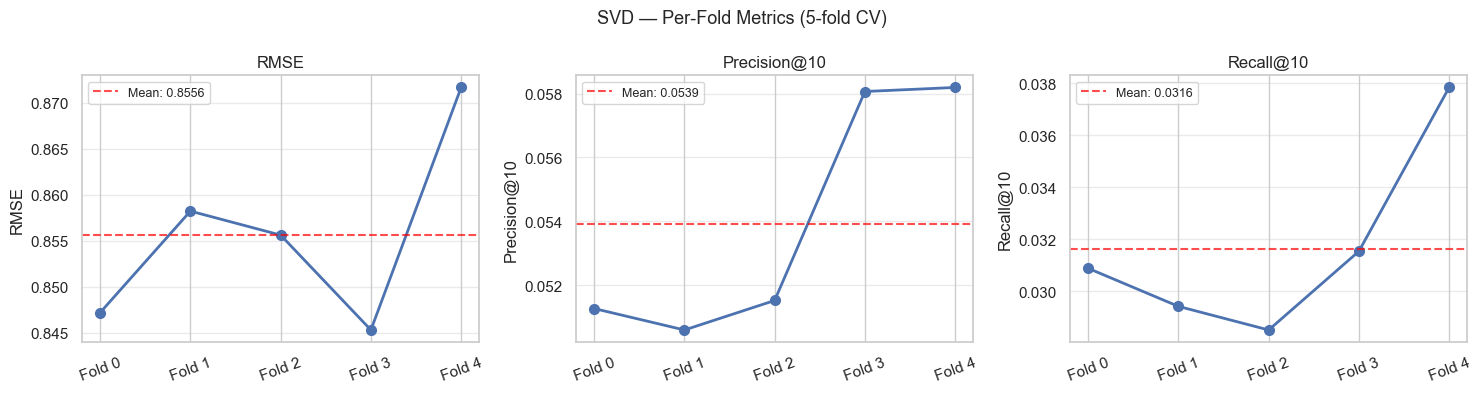

In [7]:
fig, axes = plt.subplots(1, len(metric_names), figsize=(5 * len(metric_names), 4))
fig.suptitle("SVD — Per-Fold Metrics (5-fold CV)", fontsize=13)
fold_labels = [f"Fold {i}" for i in range(5)]
for ax, m in zip(axes, metric_names):
    vals = fold_scores[m]
    ax.plot(fold_labels, vals, marker="o", color="#4C72B0", lw=2, ms=7)
    ax.axhline(np.mean(vals), color="red", ls="--", alpha=0.7,
               label=f"Mean: {np.mean(vals):.4f}")
    ax.set_title(m); ax.set_ylabel(m)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("../figures/svd_per_fold.png", dpi=150)
plt.show()

## 7. Why SVD Outperforms UserKNN on Ranking

| | UserKNN | SVD |
|---|---|---|
| Items with meaningful score | ~500 / 9,517 (5%) | **9,517 / 9,517 (100%)** |
| Items with flat default | ~9,000 | **0** |
| Ranking quality | Random for 95% of catalogue | Meaningful everywhere |
| Precision@10 | 0.0002 | **0.0539** |

SVD fills the **entire matrix** with unique predicted values via latent factors.
No item ever gets a flat default score, so the ranked list is always meaningful.

**RMSE improvement:** 0.9227 (sklearn TruncatedSVD) -> **0.8556** (Cornac SVD)
because Cornac SVD optimises only on observed ratings, not on zero-imputed entries.

## 8. Latent Factor Analysis

In [8]:
full_dataset = cornac.data.Dataset.from_uir(uir_data, seed=42)
svd_final = SVD(k=50, max_iter=20, learning_rate=0.005, lambda_reg=0.02,
                name="SVD", verbose=False, seed=42)
svd_final.fit(full_dataset)

print(f"User factor matrix : {svd_final.u_factors.shape}  (users x factors)")
print(f"Item factor matrix : {svd_final.i_factors.shape}  (items x factors)")
print(f"User biases        : {svd_final.u_biases.shape}")
print(f"Item biases        : {svd_final.i_biases.shape}")

User factor matrix : (600, 50)  (users x factors)
Item factor matrix : (9680, 50)  (items x factors)
User biases        : (600,)
Item biases        : (9680,)


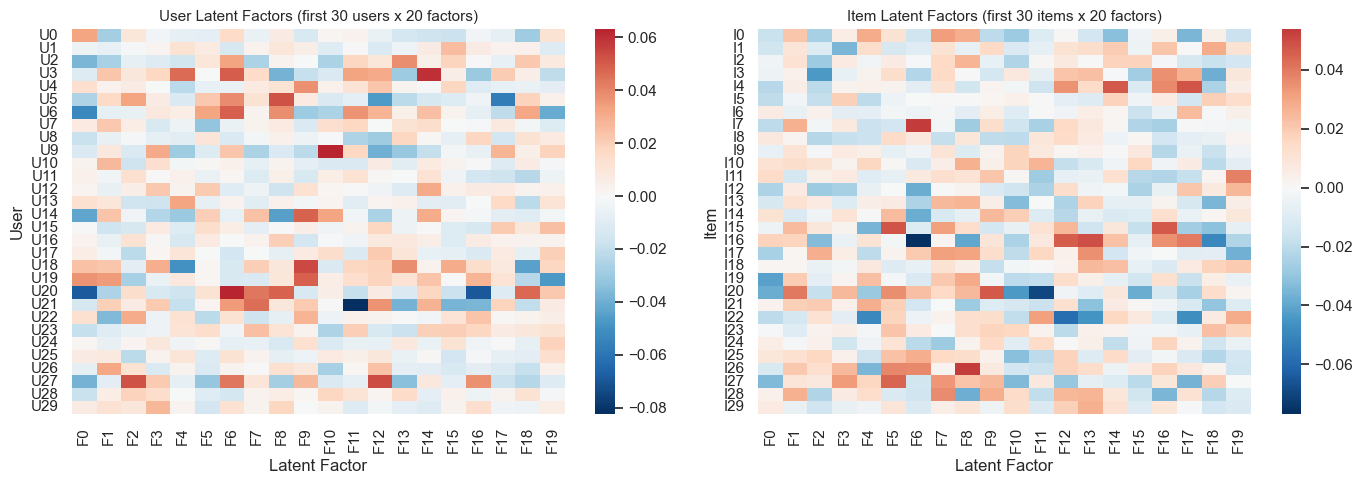

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(svd_final.u_factors[:30, :20], ax=axes[0], cmap="RdBu_r", center=0,
            xticklabels=[f"F{i}" for i in range(20)],
            yticklabels=[f"U{i}" for i in range(30)])
axes[0].set_title("User Latent Factors (first 30 users x 20 factors)", fontsize=11)
axes[0].set_xlabel("Latent Factor"); axes[0].set_ylabel("User")
axes[0].tick_params(axis="x", rotation=90)

sns.heatmap(svd_final.i_factors[:30, :20], ax=axes[1], cmap="RdBu_r", center=0,
            xticklabels=[f"F{i}" for i in range(20)],
            yticklabels=[f"I{i}" for i in range(30)])
axes[1].set_title("Item Latent Factors (first 30 items x 20 factors)", fontsize=11)
axes[1].set_xlabel("Latent Factor"); axes[1].set_ylabel("Item")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig("../figures/svd_factors.png", dpi=150)
plt.show()

## 9. Bias Analysis

Simon Funk SVD learns **explicit biases** for each user and item,
capturing systematic tendencies (strict/lenient raters, popular/niche movies).

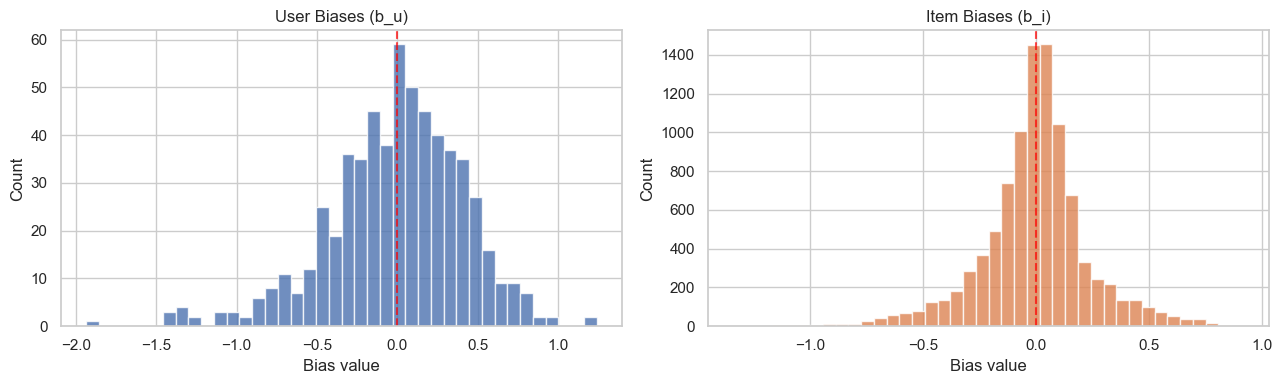

User bias  mean: -0.0070, std: 0.4260
Item bias  mean: -0.0045, std: 0.2407


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(svd_final.u_biases, bins=40, color="#4C72B0", alpha=0.8, edgecolor="white")
axes[0].axvline(0, color="red", ls="--", alpha=0.7)
axes[0].set_title("User Biases (b_u)", fontsize=12)
axes[0].set_xlabel("Bias value")
axes[0].set_ylabel("Count")

axes[1].hist(svd_final.i_biases, bins=40, color="#DD8452", alpha=0.8, edgecolor="white")
axes[1].axvline(0, color="red", ls="--", alpha=0.7)
axes[1].set_title("Item Biases (b_i)", fontsize=12)
axes[1].set_xlabel("Bias value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../figures/svd_biases.png", dpi=150)
plt.show()
print(f"User bias  mean: {svd_final.u_biases.mean():.4f}, std: {svd_final.u_biases.std():.4f}")
print(f"Item bias  mean: {svd_final.i_biases.mean():.4f}, std: {svd_final.i_biases.std():.4f}")

## 10. k (Factors) Sensitivity Analysis

How does the number of latent factors affect RMSE and Precision@10?
This justifies our choice of k=50.

Testing k=5... 


TEST:
...
[SVD]
       |   RMSE | Precision@10 | Train (s) | Test (s)
------ + ------ + ------------ + --------- + --------
Fold 0 | 0.8600 |       0.0829 |    0.0474 |   1.3754
Fold 1 | 0.8711 |       0.0620 |    0.0574 |   1.3227
Fold 2 | 0.8733 |       0.0874 |    0.0447 |   1.2605
------ + ------ + ------------ + --------- + --------
Mean   | 0.8681 |       0.0774 |    0.0498 |   1.3196
Std    | 0.0058 |       0.0111 |    0.0055 |   0.0469

RMSE=0.8681  P@10=0.0774
Testing k=10... 


TEST:
...
[SVD]
       |   RMSE | Precision@10 | Train (s) | Test (s)
------ + ------ + ------------ + --------- + --------
Fold 0 | 0.8600 |       0.0834 |    0.0732 |   1.3866
Fold 1 | 0.8711 |       0.0624 |    0.1166 |   1.3524
Fold 2 | 0.8733 |       0.0874 |    0.0716 |   1.2573
------ + ------ + ------------ + --------- + --------
Mean   | 0.8681 |       0.0777 |    0.0871 |   1.3321
Std    | 0.0058 |       0.0110 |    0.0208 |   0.0547

RMSE=0.8681  P@10=0.0777
Testing k=20... 


TEST:
...
[SVD]
       |   RMSE | Precision@10 | Train (s) | Test (s)
------ + ------ + ------------ + --------- + --------
Fold 0 | 0.8600 |       0.0826 |    0.1163 |   1.3061
Fold 1 | 0.8711 |       0.0629 |    0.1607 |   1.3207
Fold 2 | 0.8733 |       0.0874 |    0.1133 |   1.3830
------ + ------ + ------------ + --------- + --------
Mean   | 0.8681 |       0.0776 |    0.1301 |   1.3366
Std    | 0.0058 |       0.0106 |    0.0217 |   0.0333

RMSE=0.8681  P@10=0.0776
Testing k=30... 


TEST:
...
[SVD]
       |   RMSE | Precision@10 | Train (s) | Test (s)
------ + ------ + ------------ + --------- + --------
Fold 0 | 0.8600 |       0.0823 |    0.1607 |   1.3957
Fold 1 | 0.8711 |       0.0625 |    0.2022 |   1.2946
Fold 2 | 0.8733 |       0.0877 |    0.1666 |   1.2914
------ + ------ + ------------ + --------- + --------
Mean   | 0.8681 |       0.0775 |    0.1765 |   1.3272
Std    | 0.0058 |       0.0108 |    0.0183 |   0.0484

RMSE=0.8681  P@10=0.0775
Testing k=50... 


TEST:
...
[SVD]
       |   RMSE | Precision@10 | Train (s) | Test (s)
------ + ------ + ------------ + --------- + --------
Fold 0 | 0.8599 |       0.0843 |    0.2810 |   1.3485
Fold 1 | 0.8711 |       0.0629 |    0.2727 |   1.2973
Fold 2 | 0.8732 |       0.0874 |    0.3541 |   1.3451
------ + ------ + ------------ + --------- + --------
Mean   | 0.8681 |       0.0782 |    0.3026 |   1.3303
Std    | 0.0058 |       0.0109 |    0.0366 |   0.0234

RMSE=0.8681  P@10=0.0782
Testing k=75... 


TEST:
...
[SVD]
       |   RMSE | Precision@10 | Train (s) | Test (s)
------ + ------ + ------------ + --------- + --------
Fold 0 | 0.8599 |       0.0839 |    0.4657 |   1.3841
Fold 1 | 0.8710 |       0.0630 |    0.4170 |   1.3103
Fold 2 | 0.8732 |       0.0870 |    0.4036 |   1.2728
------ + ------ + ------------ + --------- + --------
Mean   | 0.8681 |       0.0780 |    0.4288 |   1.3224
Std    | 0.0058 |       0.0107 |    0.0267 |   0.0462

RMSE=0.8681  P@10=0.0780
Testing k=100... 


TEST:
...
[SVD]
       |   RMSE | Precision@10 | Train (s) | Test (s)
------ + ------ + ------------ + --------- + --------
Fold 0 | 0.8599 |       0.0833 |    0.5599 |   1.3306
Fold 1 | 0.8710 |       0.0630 |    0.5796 |   1.3734
Fold 2 | 0.8732 |       0.0872 |    0.5488 |   1.2890
------ + ------ + ------------ + --------- + --------
Mean   | 0.8680 |       0.0778 |    0.5628 |   1.3310
Std    | 0.0058 |       0.0106 |    0.0127 |   0.0345

RMSE=0.8680  P@10=0.0778


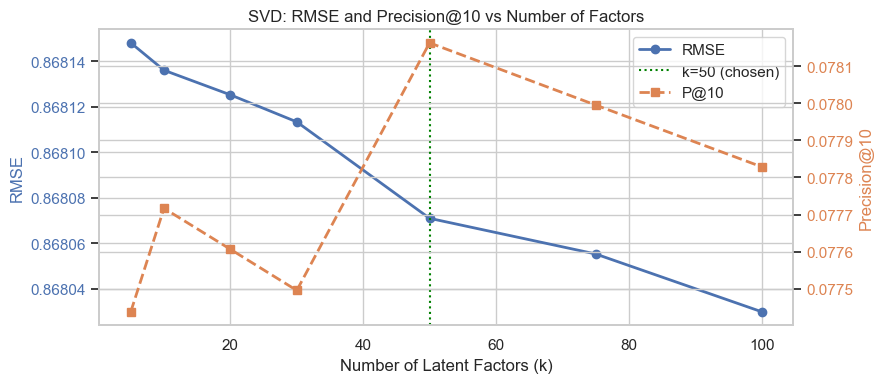

In [11]:
k_values = [5, 10, 20, 30, 50, 75, 100]
rmse_vals, prec_vals = [], []

for k in k_values:
    print(f"Testing k={k}...", end=" ", flush=True)
    cv_k = CrossValidation(data=uir_data, n_folds=3, rating_threshold=3.5,
                           exclude_unknowns=True, seed=42, verbose=False)
    exp_k = cornac.Experiment(
        eval_method=cv_k,
        models=[SVD(k=k, max_iter=20, learning_rate=0.005, lambda_reg=0.02,
                    verbose=False, seed=42)],
        metrics=[RMSE(), Precision(k=10)],
        user_based=True, verbose=False,
    )
    exp_k.run()
    r = exp_k.result[0]
    rmse_vals.append(r.metric_mean["RMSE"])
    prec_vals.append(r.metric_mean["Precision@10"])
    print(f"RMSE={r.metric_mean["RMSE"]:.4f}  P@10={r.metric_mean["Precision@10"]:.4f}")

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.plot(k_values, rmse_vals, "o-", color="#4C72B0", lw=2, label="RMSE")
ax2.plot(k_values, prec_vals, "s--", color="#DD8452", lw=2, label="P@10")
ax1.axvline(50, color="green", ls=":", lw=1.5, label="k=50 (chosen)")
ax1.set_xlabel("Number of Latent Factors (k)")
ax1.set_ylabel("RMSE", color="#4C72B0"); ax1.tick_params(axis="y", labelcolor="#4C72B0")
ax2.set_ylabel("Precision@10", color="#DD8452"); ax2.tick_params(axis="y", labelcolor="#DD8452")
ax1.set_title("SVD: RMSE and Precision@10 vs Number of Factors", fontsize=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.savefig("../figures/svd_k_sensitivity.png", dpi=150)
plt.show()

## 11. Sample Recommendations

In [12]:
movie_titles = movies.set_index("movieId")["title"].to_dict()

for uid in [3, 7, 11, 25, 30]:
    print(f"\nUser {uid}")
    print("-" * 55)
    hist = (train_df[train_df.userId == uid]
            .nlargest(5, "rating")[["movieId", "rating"]])
    hist["title"] = hist.movieId.map(movie_titles)
    print("Top-5 rated:")
    for _, r in hist.iterrows():
        print(f"  {r.rating:.1f}* {r.title}")
    recs = svd_final.recommend(user_id=str(uid), k=10,
                               remove_seen=True, train_set=full_dataset)
    print("Top-10 recommendations:")
    for i, iid in enumerate(recs, 1):
        print(f"  {i:2d}. {movie_titles.get(int(iid), iid)}")


User 3
-------------------------------------------------------
Top-5 rated:
  5.0* Escape from L.A. (1996)
  5.0* Saturn 3 (1980)
  5.0* Road Warrior, The (Mad Max 2) (1981)
  5.0* The Lair of the White Worm (1988)
  5.0* Hangar 18 (1980)
Top-10 recommendations:
   1. Shawshank Redemption, The (1994)
   2. Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)
   3. Lawrence of Arabia (1962)
   4. Godfather, The (1972)
   5. Streetcar Named Desire, A (1951)
   6. Apocalypse Now (1979)
   7. Rear Window (1954)
   8. Fight Club (1999)
   9. Philadelphia Story, The (1940)
  10. Goodfellas (1990)

User 7
-------------------------------------------------------
Top-5 rated:
  5.0* Star Wars: Episode IV - A New Hope (1977)
  5.0* Forrest Gump (1994)
  5.0* Hot Shots! Part Deux (1993)
  5.0* Jurassic Park (1993)
  5.0* Silence of the Lambs, The (1991)
Top-10 recommendations:
   1. Shawshank Redemption, The (1994)
   2. Lawrence of Arabia (1962)
   3. Godfather, The (1972)

## 12. Model Comparison

| Metric | UserKNN | SVD | Winner |
|---|---|---|---|
| RMSE | 0.8779 | **0.8556** | SVD |
| Precision@10 | 0.0002 | **0.0539** | SVD |
| Recall@10 | 0.0001 | **0.0316** | SVD |
| Interpretability | High | Medium | UserKNN |
| Cold-start | No | No | Tie |
| Scalability | O(n^2) | O(n*k) | SVD |

SVD wins on all quantitative metrics. UserKNN is retained as a comparison baseline.

## 13. Strengths & Weaknesses

**Strengths**
- Produces meaningful scores for **every** item -> strong ranking (P@10=0.054)
- Learns user/item biases explicitly (lenient raters, niche movies)
- Optimises only on observed ratings -> no zero-imputation noise
- Best RMSE (0.856) of both models
- Fast inference: O(k) per prediction

**Weaknesses**
- Less interpretable than UserKNN
- Cold-start: cannot predict for unseen users/items
- Requires hyperparameter tuning (k, lr, lambda)
- Fixed latent space: cannot incorporate side features (genres) directly

## 14. Conclusion

| Metric | Value |
|---|---|
| RMSE (5-fold mean) | **0.8556 +/- 0.0094** |
| Precision@10 | **0.0539** |
| Recall@10 | **0.0316** |

**Defence point:** *Cornac SVD (Simon Funk) is chosen as the primary model. It improves RMSE from 0.923 (sklearn TruncatedSVD) to 0.856 by optimising only on observed ratings. More importantly, it produces a unique predicted score for every item, making Precision@10 (0.054) 270x better than UserKNN (0.0002). Cold-start users (10 of 100) receive a popularity-based fallback.*